# Disaster Tweet Classification: Exploratory Data Analysis & Text Preprocessing

**Dataset:** HumAID (Humanitarian Aid Disaster Tweets across 10 Crisis Events & Categories)  
**Authors:** Md. Nayeem & MD Jahid Hasan Jim  
**Objective:** Comprehensive exploratory data analysis (EDA), data integrity verification, social media noise profiling, text cleaning (Raw vs. Clean), n-gram extraction (Unigram, Bigram, Trigram), and clean dataset export.

---
### Text Preprocessing Transformations & Pipeline Examples

The table below details how social media noise, crisis abbreviations, emojis, contractions, and encoding artifacts are transformed in this notebook:

| Artifact / Feature | Raw Tweet Example | Cleaned Output | NLP Rationale |
| :--- | :--- | :--- | :--- |
| **HTML Entities** | `Our thoughts &amp; prayers are with Ecuador` | `our thoughts & prayers are with ecuador` | Unescapes corrupted HTML web entities (`&amp;`, `&lt;`, `&gt;`, `&#39;`). |
| **Smart Quotes & Typography** | `don’t`, `“urgent”`, `safe—accounted` | `don't`, `"urgent"`, `safe - accounted` | Normalizes curly quotes (`’`, `‘`, `“`, `”`) and typographic dashes (`—`, `–`). |
| **User Mentions & URLs** | `PLEASE DONATE @TheStruts @UNICEF https://t.co/xyz` | `please donate` | Removes account handles and external links that add vocabulary noise. |
| **Hashtag Segmentation** | `#EcuadorEarthquake #PrayForEcuador` | `ecuador earthquake pray for ecuador` | Splits PascalCase/camelCase disaster tags into individual semantic tokens. |
| **Emergency Emojis** | `Prayers 🙏 for victims 💔 🚨 🔥 🌊 🆘` | `prayers prayer support for victims heartbreak grief emergency warning alert fire wildfire disaster flood tsunami water surge urgent help request emergency` | Translates domain emojis into descriptive disaster vocabulary tokens. |
| **Contraction Expansion** | `can't believe`, `won't stop`, `we're safe` | `cannot believe`, `will not stop`, `we are safe` | Expands colloquial contractions into standardized base words. |
| **Disaster Slang** | `pls send emerg evac vols & info b4 night` | `please send emergency evacuation volunteers & information before night` | Translates informal crisis abbreviations into clear language tokens. |
| **Retweet Prefixes** | `RT @NBCLA: Here are ways you can help` | `here are ways you can help` | Strips redundant retweet tags (`RT`, `rt :`) and orphaned colon artifacts. |
| **Character Elongation** | `sooooo scary`, `pleeease help` | `soo scary`, `pleease help` | De-elongates repetitive characters to prevent vocabulary explosion. |
| **Encoding Mojibake** | `SCARY! ὤ2ὤFἿB #earthquake`, `️` | `scary! 2 f b earthquake` | Strips orphaned UTF-16 surrogate residue and invisible unicode control codes. |

---
### Notebook Architecture
1. **Dataset Loading & Integrity Verification:** Validation of parquet splits, missing values, duplicates, and leakage.
2. **Class Distribution & Imbalance Analysis:** Frequency profiling and inverse class weighting analysis.
3. **Raw Text Profiling:** Length distributions, entity counts (URLs, mentions, hashtags).
4. **Disaster Domain Text Cleaning:** Contraction expansion, slang translation, emoji mapping, hashtag segmentation.
5. **Before vs. After Cleaning Comparison:** Quantitative and visual validation of Raw vs. Clean text.
6. **N-Gram Analysis:** Top Unigrams, Bigrams, and Trigrams across corpus and per disaster class.
7. **Clean Dataset Export:** Saving `train_clean`, `validation_clean`, and `test_clean` parquet and CSV files.

In [10]:
import os
import re
import html
import string
import unicodedata
from collections import Counter
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

# Visualization Aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

# Local dataset directory
DATA_DIR = Path("../dataset") if Path("../dataset").exists() else Path("dataset")

# Load Parquet Splits directly
train_df = pd.read_parquet(DATA_DIR / "train.parquet")
val_df = pd.read_parquet(DATA_DIR / "validation.parquet")
test_df = pd.read_parquet(DATA_DIR / "test.parquet")

print(f"[+] Loaded splits from: {DATA_DIR.resolve()}")
print(f"Train Split : {train_df.shape} ({len(train_df):,} samples)")
print(f"Val Split   : {val_df.shape} ({len(val_df):,} samples)")
print(f"Test Split  : {test_df.shape} ({len(test_df):,} samples)")

[+] Loaded splits from: D:\nlp-project\dataset
Train Split : (53531, 2) (53,531 samples)
Val Split   : (7793, 2) (7,793 samples)
Test Split  : (15160, 2) (15,160 samples)


## 1. Dataset Overview & Integrity Verification

In this section, we verify:
- Complete absence of missing/null values across text and label fields.
- Duplicate detection (Exact vs Normalized case-insensitive strings).
- Cross-split contamination & data leakage (checking if test/validation samples appear in train).

In [11]:
# 1. Missing Values Check
splits = {'Train': train_df, 'Validation': val_df, 'Test': test_df}
missing_summary = pd.DataFrame({
    name: df.isnull().sum() for name, df in splits.items()
})
print("=== Missing Value Summary ===")
print(missing_summary)

# 2. Duplicate Analysis within splits
exact_dups = {name: df.duplicated(subset=['tweet_text']).sum() for name, df in splits.items()}
norm_dups = {name: df['tweet_text'].str.lower().str.strip().duplicated().sum() for name, df in splits.items()}

# 3. Cross-Split Contamination (Train vs Val, Train vs Test, Val vs Test)
train_texts = set(train_df['tweet_text'].str.lower().str.strip())
val_texts = set(val_df['tweet_text'].str.lower().str.strip())
test_texts = set(test_df['tweet_text'].str.lower().str.strip())

train_val_overlap = len(train_texts.intersection(val_texts))
train_test_overlap = len(train_texts.intersection(test_texts))
val_test_overlap = len(val_texts.intersection(test_texts))

integrity_df = pd.DataFrame([
    {"Split": "Train", "Samples": len(train_df), "Exact Dups": exact_dups['Train'], "Normalized Dups": norm_dups['Train'], "Overlap with Test": train_test_overlap},
    {"Split": "Validation", "Samples": len(val_df), "Exact Dups": exact_dups['Validation'], "Normalized Dups": norm_dups['Validation'], "Overlap with Test": val_test_overlap},
    {"Split": "Test", "Samples": len(test_df), "Exact Dups": exact_dups['Test'], "Normalized Dups": norm_dups['Test'], "Overlap with Test": "-"}
])

print("\n=== Dataset Integrity & Overlap Report ===")
print(integrity_df.to_string(index=False))

=== Missing Value Summary ===
             Train  Validation  Test
tweet_text       0           0     0
class_label      0           0     0

=== Dataset Integrity & Overlap Report ===
     Split  Samples  Exact Dups  Normalized Dups Overlap with Test
     Train    53531           0                0                 0
Validation     7793           1                1                 0
      Test    15160           1                1                 -


## 2. Humanitarian Class Distribution & Imbalance Analysis

HumAID categorizes crisis-related tweets into 10 humanitarian aid categories. Understanding class imbalance is essential for designing appropriate loss functions (e.g., class-weighted Cross-Entropy) and evaluating macro vs weighted metrics.

Total Unique Classes : 10
Majority Class       : rescue_volunteering_or_donation_effort (14,891.0 train samples)
Minority Class       : missing_or_found_people (250.0 train samples)
Class Imbalance Ratio: 59.56 : 1

=== Class Distribution Across Splits ===
                                        Train_count  Train_pct  \
rescue_volunteering_or_donation_effort        14891      27.82   
other_relevant_information                     8501      15.88   
sympathy_and_support                           6250      11.68   
infrastructure_and_utility_damage              5715      10.68   
injured_or_dead_people                         5110       9.55   
not_humanitarian                               4407       8.23   
caution_and_advice                             3774       7.05   
displaced_people_and_evacuations               2800       5.23   
requests_or_urgent_needs                       1833       3.42   
missing_or_found_people                         250       0.47   

                

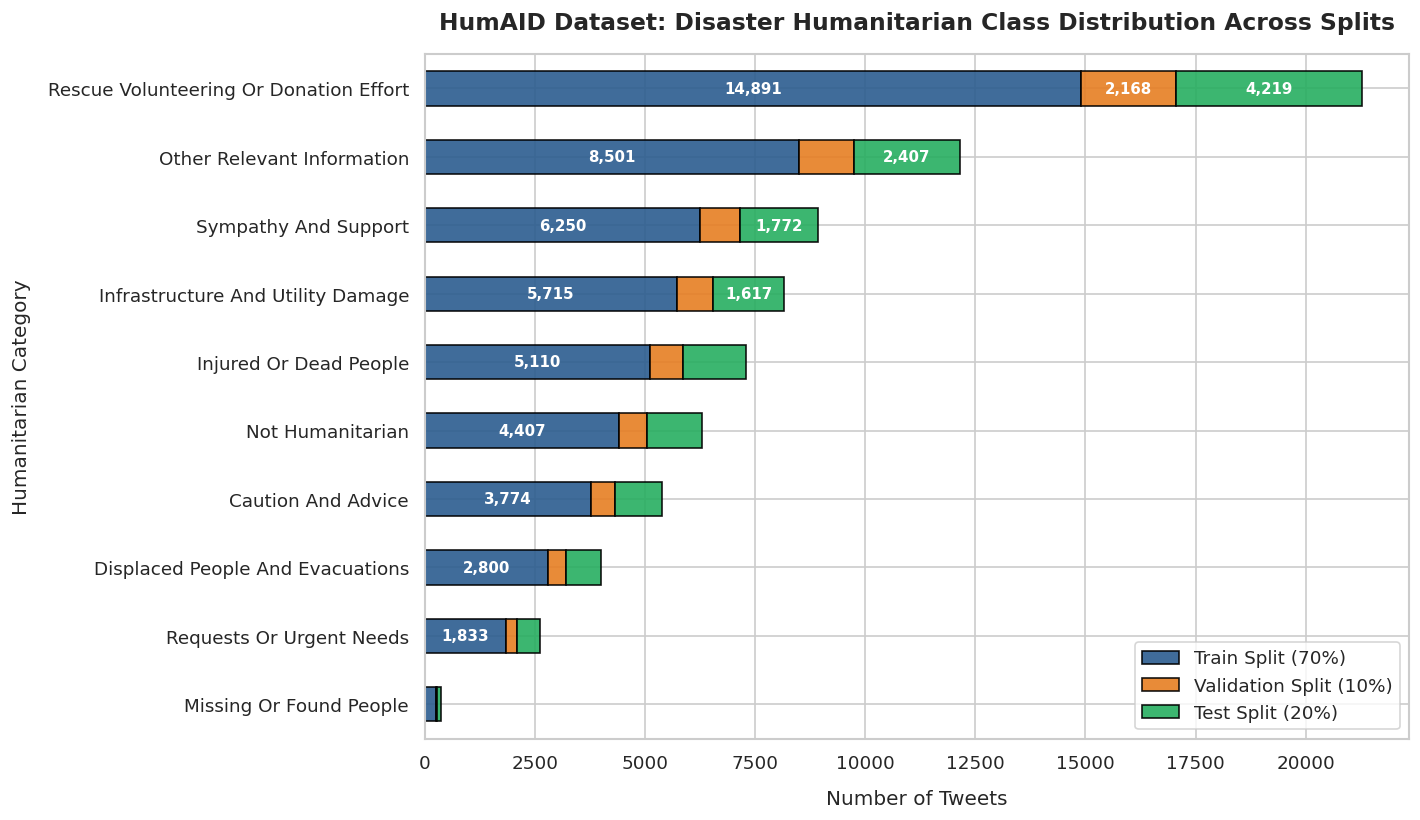

In [12]:
# Compile Class Distribution Table
classes = sorted(train_df['class_label'].unique())
num_classes = len(classes)
total_samples = len(train_df) + len(val_df) + len(test_df)

class_dist_df = pd.DataFrame(index=classes)
for name, df in splits.items():
    counts = df['class_label'].value_counts()
    class_dist_df[f'{name}_count'] = class_dist_df.index.map(counts).fillna(0).astype(int)
    class_dist_df[f'{name}_pct'] = (class_dist_df[f'{name}_count'] / len(df) * 100).round(2)

class_dist_df['Total_count'] = class_dist_df['Train_count'] + class_dist_df['Validation_count'] + class_dist_df['Test_count']
class_dist_df['Total_pct'] = (class_dist_df['Total_count'] / total_samples * 100).round(2)
class_dist_df = class_dist_df.sort_values(by='Total_count', ascending=False)

# Compute Imbalance Ratio
max_c = class_dist_df['Train_count'].max()
min_c = class_dist_df['Train_count'].min()
imbalance_ratio = max_c / min_c

print(f"Total Unique Classes : {num_classes}")
print(f"Majority Class       : {class_dist_df.index[0]} ({class_dist_df.iloc[0]['Train_count']:,} train samples)")
print(f"Minority Class       : {class_dist_df.index[-1]} ({class_dist_df.iloc[-1]['Train_count']:,} train samples)")
print(f"Class Imbalance Ratio: {imbalance_ratio:.2f} : 1")
print("\n=== Class Distribution Across Splits ===")
print(class_dist_df[['Train_count', 'Train_pct', 'Validation_count', 'Test_count', 'Total_count', 'Total_pct']])

# Visualize Class Distribution Across Splits
fig, ax = plt.subplots(figsize=(12, 7))
plot_df = class_dist_df[['Train_count', 'Validation_count', 'Test_count']].copy()
plot_df.index = [idx.replace('_', ' ').title() for idx in plot_df.index]

colors = ['#2b5c8f', '#e67e22', '#27ae60']
plot_df.plot(kind='barh', stacked=True, ax=ax, color=colors, edgecolor='black', alpha=0.9)

ax.set_title('HumAID Dataset: Disaster Humanitarian Class Distribution Across Splits', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Number of Tweets', fontsize=12, labelpad=10)
ax.set_ylabel('Humanitarian Category', fontsize=12, labelpad=10)
ax.legend(['Train Split (70%)', 'Validation Split (10%)', 'Test Split (20%)'], frameon=True, fontsize=11, loc='lower right')
ax.invert_yaxis()

for p in ax.patches:
    width = p.get_width()
    if width > 1500:
        ax.annotate(f'{int(width):,}',
                    (p.get_x() + width / 2, p.get_y() + p.get_height() / 2),
                    ha='center', va='center', color='white', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

## 3. Raw Text Characteristics & Social Media Noise Profiling

Disaster tweets feature heavy social media artifacts including HTTP URLs, user mentions (`@user`), hashtags (`#disaster`), and non-standard abbreviations. Here we measure their frequency and analyze text length distributions.

=== Social Media Entity Statistics ===
                         Train  Validation      Test
Total URLs                6.00        0.00      1.00
Total Mentions        33250.00     4721.00   9329.00
Total Hashtags        66482.00     9864.00  18777.00
Total Digits              0.00        0.00      0.00
All-Caps Words            0.00        0.00      0.00
Avg URLs / Tweet          0.00        0.00      0.00
Avg Mentions / Tweet      0.62        0.61      0.62
Avg Hashtags / Tweet      1.24        1.27      1.24

=== Tweet Length Distribution Summary ===
     Split  Word Mean  Word Median  Word Std  Word Min  Word Max  Word 95th %  Word 99th %  Char Mean  Char 95th %  Char Max
     Train      22.11           19     10.71         3        96           44           50     141.62          273       945
Validation      22.01           19     10.69         3        64           44           49     141.08          273       475
      Test      22.12           19     10.72         3        99  

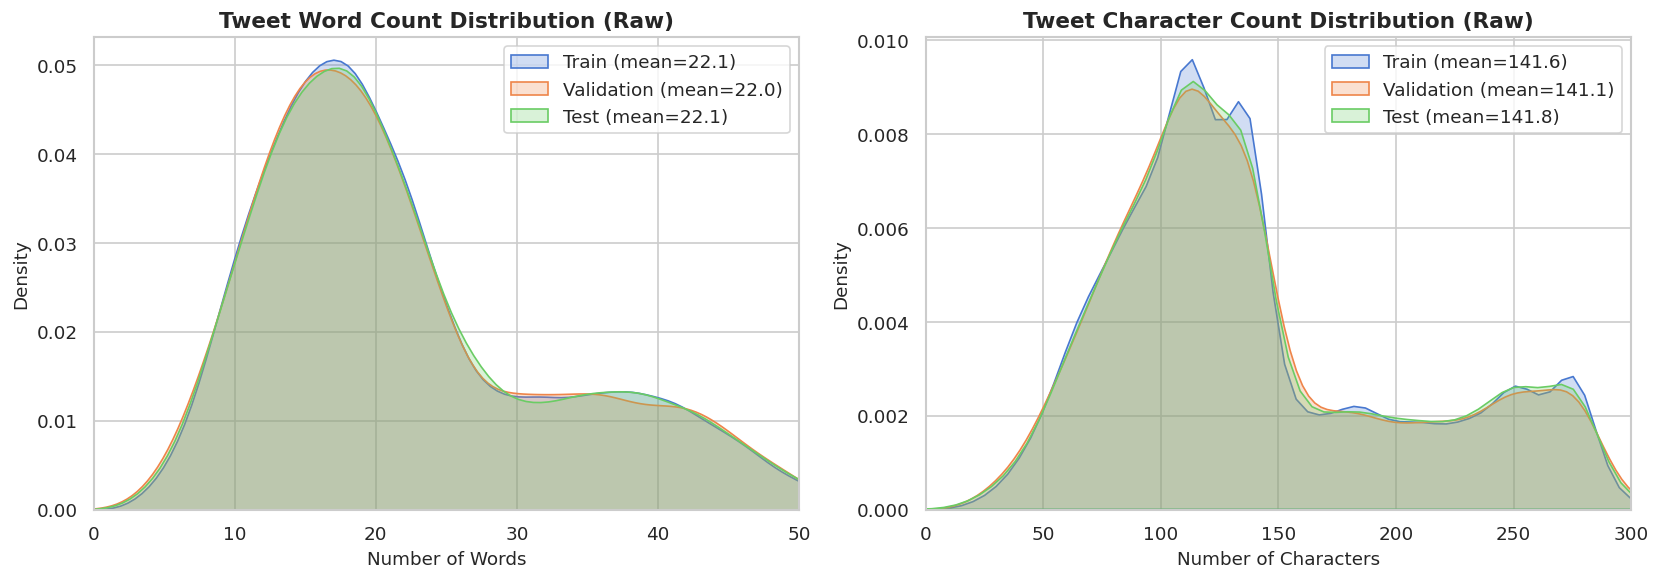

In [13]:
# Entity Extraction & Noise Characterization
def extract_entity_stats(df: pd.DataFrame, text_col: str = 'tweet_text') -> dict:
    urls = df[text_col].str.count(r'https?://\S+|www\.\S+').sum()
    mentions = df[text_col].str.count(r'@\w+').sum()
    hashtags = df[text_col].str.count(r'#\w+').sum()
    digits = df[text_col].str.count(r'\d+').sum()
    allcaps = df[text_col].str.count(r'[A-Z]{2,}').sum()
    return {
        'Total URLs': int(urls),
        'Total Mentions': int(mentions),
        'Total Hashtags': int(hashtags),
        'Total Digits': int(digits),
        'All-Caps Words': int(allcaps),
        'Avg URLs / Tweet': round(urls / len(df), 2),
        'Avg Mentions / Tweet': round(mentions / len(df), 2),
        'Avg Hashtags / Tweet': round(hashtags / len(df), 2)
    }

entity_summary = pd.DataFrame({
    name: extract_entity_stats(df) for name, df in splits.items()
})
print("=== Social Media Entity Statistics ===")
print(entity_summary)

# Length Statistics (Words and Characters)
length_records = []
for name, df in splits.items():
    words = df['tweet_text'].apply(lambda x: len(str(x).split()))
    chars = df['tweet_text'].str.len()
    length_records.append({
        'Split': name,
        'Word Mean': round(words.mean(), 2),
        'Word Median': int(words.median()),
        'Word Std': round(words.std(), 2),
        'Word Min': int(words.min()),
        'Word Max': int(words.max()),
        'Word 95th %': int(np.percentile(words, 95)),
        'Word 99th %': int(np.percentile(words, 99)),
        'Char Mean': round(chars.mean(), 2),
        'Char 95th %': int(np.percentile(chars, 95)),
        'Char Max': int(chars.max())
    })

print("\n=== Tweet Length Distribution Summary ===")
print(pd.DataFrame(length_records).to_string(index=False))

# Visualization: KDE of Word / Character Lengths
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Word Count Distribution
for name, df in splits.items():
    w_len = df['tweet_text'].apply(lambda x: len(str(x).split()))
    sns.kdeplot(w_len, ax=axes[0], label=f"{name} (mean={w_len.mean():.1f})", fill=True, alpha=0.25)
axes[0].set_title('Tweet Word Count Distribution (Raw)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Words', fontsize=11)
axes[0].set_ylabel('Density', fontsize=11)
axes[0].set_xlim(0, 50)
axes[0].legend(frameon=True)

# Plot 2: Character Count Distribution
for name, df in splits.items():
    c_len = df['tweet_text'].str.len()
    sns.kdeplot(c_len, ax=axes[1], label=f"{name} (mean={c_len.mean():.1f})", fill=True, alpha=0.25)
axes[1].set_title('Tweet Character Count Distribution (Raw)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Characters', fontsize=11)
axes[1].set_ylabel('Density', fontsize=11)
axes[1].set_xlim(0, 300)
axes[1].legend(frameon=True)

plt.tight_layout()
plt.show()

## 4. Disaster Domain Text Cleaning Pipeline

We implement a domain-aware text cleaning pipeline designed specifically for disaster crisis NLP:
- **HTML Unescaping:** Decodes HTML entities (e.g. `&amp;` to `&`, `&lt;` to `<`).
- **Contraction Expansion:** Normalizes colloquial English contractions (`can't` -> `cannot`, `won't` -> `will not`).
- **Disaster Slang Normalization:** Translates short emergency abbreviations (`pls` -> `please`, `emerg` -> `emergency`, `evac` -> `evacuation`, `victs` -> `victims`).
- **Domain Emoji Translation:** Translates emojis into informative disaster semantics (e.g. prayer emoji -> `prayer support`, fire emoji -> `fire wildfire disaster`, siren emoji -> `emergency warning alert`).
- **Hashtag CamelCase Segmentation:** Splits compound disaster hashtags (`#HurricaneHarvey` -> `Hurricane Harvey`).
- **URL, Mention, and Whitespace Normalization:** Strips external links, handles user mentions, de-elongates repetitive characters, and trims excess whitespace.

In [ ]:
# Preprocessing Lexicons
CONTRACTIONS = {
    "can't": "cannot", "won't": "will not", "n't": " not", "'re": " are",
    "'s": " is", "'d": " would", "'ll": " will", "'t": " not", "'ve": " have",
    "'m": " am", "i'm": "i am", "we're": "we are", "they're": "they are",
    "it's": "it is", "there's": "there is", "that's": "that is", "what's": "what is",
    "let's": "let us", "he's": "he is", "she's": "she is", "who's": "who is",
    "ain't": "is not", "didn't": "did not", "doesn't": "does not", "don't": "do not",
    "hadn't": "had not", "hasn't": "has not", "haven't": "have not", "isn't": "is not",
    "shouldn't": "should not", "wasn't": "was not", "weren't": "were not", "wouldn't": "would not"
}

DISASTER_SLANG = {
    r"\bpls\b": "please", r"\bplz\b": "please", r"\bthx\b": "thanks",
    r"\bu\b": "you", r"\bur\b": "your", r"\br\b": "are",
    r"\bw/\b": "with", r"\bw/o\b": "without", r"\bb4\b": "before",
    r"\bmsg\b": "message", r"\binfo\b": "information", r"\bemerg\b": "emergency",
    r"\bevac\b": "evacuation", r"\bevacs\b": "evacuations", r"\bvicts\b": "victims",
    r"\bgov\b": "government", r"\bdept\b": "department", r"\bvol\b": "volunteer",
    r"\bhrs\b": "hours", r"\bmins\b": "minutes", r"\bapprox\b": "approximately",
    r"\btxt\b": "text", r"\bpm\b": "afternoon", r"\bam\b": "morning"
}

EMOJI_TRANSLATIONS = {
    "🙏": " prayer support ", "💔": " heartbreak grief ", "❤️": " love sympathy ",
    "❤": " love sympathy ", "♥": " love sympathy ", "🖤": " grief sympathy ",
    "😢": " crying sorrow sadness ", "😭": " weeping tragedy ", "☹": " sad sorrow ",
    "😞": " sad sorrow ", "🕯️": " mourning memorial ", "🕯": " mourning memorial ",
    "🚨": " emergency warning alert ", "⚠️": " danger warning caution ",
    "⚠": " danger warning caution ", "🔥": " fire wildfire disaster ",
    "🌊": " flood tsunami water surge ", "🌧️": " rain storm hurricane ",
    "🌧": " rain storm hurricane ", "🌪️": " tornado storm ", "🌪": " tornado storm ",
    "⚡": " storm lightning ", "🆘": " urgent help request emergency ",
    "❗": " urgent alert ", "‼": " urgent alert ",
    "🏠": " shelter home house ", "🏡": " shelter home house ",
    "🏥": " hospital medical clinic ", "🚑": " ambulance medical emergency ",
    "🚁": " rescue helicopter ", "🤝": " helping relief support ",
    "📦": " relief aid supplies ", "🍲": " food relief distribution ",
    "🍞": " food relief distribution ", "💧": " clean water relief ",
    "👏": " appreciation support ", "✅": " confirmed verified ", "✔": " confirmed verified ",
    "🩸": " blood donation request "
}

UNICODE_NORM = {
    '’': "'", '‘': "'", '`': "'", '´': "'", '′': "'",
    '“': '"', '”': '"', '″': '"',
    '—': ' - ', '–': ' - ', '―': ' - ',
    '…': ' ', '•': ' ', '·': ' ', '・': ' ',
    '\u00a0': ' ', '\ufe0f': '', '\ufe0e': '',
    '\u200b': '', '\u200c': '', '\u200d': '', '\ufeff': '',
    '\u2060': '', '\u2066': '', '\u2069': '', '\u2063': '',
}

def split_camel_case_word(match):
    word = match.group(1)
    s1 = re.sub(r'([a-z0-9])([A-Z])', r'\1 \2', word)
    s2 = re.sub(r'([A-Z]+)([A-Z][a-z])', r'\1 \2', s1)
    return ' ' + s2 + ' '

def clean_text(text: str) -> str:
    """Comprehensive domain cleaning for disaster crisis tweets."""
    if not isinstance(text, str):
        return ""
    
    # 1. HTML unescape
    text = html.unescape(text)
    
    # 2. Normalize smart punctuation and invisible unicode markers
    for k, v in UNICODE_NORM.items():
        text = text.replace(k, v)
        
    # 3. Translate domain emojis
    for em, rep in EMOJI_TRANSLATIONS.items():
        text = text.replace(em, rep)
        
    # 4. Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    
    # 5. Remove Twitter handles / user mentions
    text = re.sub(r'@\w+', ' ', text)
    
    # 6. Segment hashtags
    text = re.sub(r'#(\w+)', split_camel_case_word, text)
    
    # 7. Strip leftover emojis, skin tone modifiers, flags, and corrupted surrogate mojibake
    text = re.sub(r'[\U00010000-\U0010ffff]', ' ', text)
    text = re.sub(r'[\u1f00-\u1fff\ue000-\uf8ff\uff00-\uffef\u0370-\u03ff\u2600-\u26ff\u2700-\u27bf]', ' ', text)
    
    # 8. Normalize accented Latin characters
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8', 'ignore')
    
    # 9. Lowercase
    text = text.lower()
    
    # 10. Expand contractions
    for c, exp in CONTRACTIONS.items():
        text = text.replace(c, exp)
        
    # 11. Disaster slang normalization
    for p, rep in DISASTER_SLANG.items():
        text = re.sub(p, rep, text, flags=re.IGNORECASE)
        
    # 12. Clean Retweet prefix remnants
    text = re.sub(r'\brt\b\s*:?', ' ', text, flags=re.IGNORECASE)
    
    # 13. De-elongate repetitive chars (e.g. "sooooo" -> "soo")
    text = re.sub(r'([a-zA-Z])\1{2,}', r'\1\1', text)
    
    # 14. Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("[+] Text cleaning function defined successfully.")

## 5. Before vs. After Cleaning Comparative Analysis

We evaluate the impact of the cleaning pipeline on real disaster tweets, comparing raw text vs. cleaned outputs across word counts, character lengths, and vocabulary reduction.

=== Sample Tweet Transformations: Raw vs. Clean ===

[12] Target Class: rescue_volunteering_or_donation_effort
  [RAW]   : Weve raised over $10,000 today from 36 donors. Humbled by the support, which will buy supplies in Quito that
  [CLEAN] : weve raised over $10,000 today from 36 donors. humbled by the support, which will buy supplies in quito that
--------------------------------------------------------------------------------
[105] Target Class: injured_or_dead_people
  [RAW]   : NEW: Death toll from earthquake in Ecuador reached 233, 1500+ injured
  [CLEAN] : new: death toll from earthquake in ecuador reached 233, 1500+ injured
--------------------------------------------------------------------------------
[520] Target Class: injured_or_dead_people
  [RAW]   : UPDATE: Death toll from earthquake in Ecuador raised to 233
  [CLEAN] : update: death toll from earthquake in ecuador raised to 233
--------------------------------------------------------------------------------
[1024] Tar

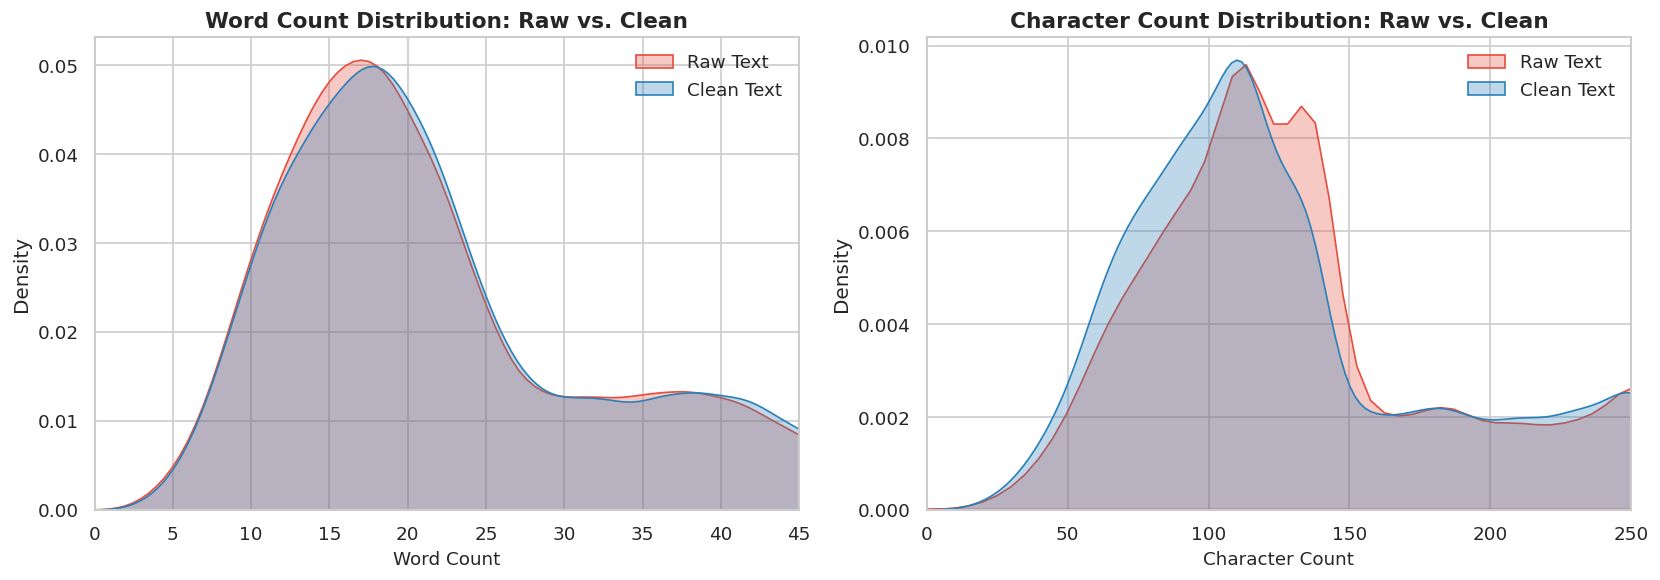

In [15]:
# Sample Transformations: Raw vs. Clean
sample_indices = [12, 105, 520, 1024, 2500]
print("=== Sample Tweet Transformations: Raw vs. Clean ===\n")
for idx in sample_indices:
    raw = train_df.iloc[idx]['tweet_text']
    lbl = train_df.iloc[idx]['class_label']
    print(f"[{idx}] Target Class: {lbl}")
    print(f"  [RAW]   : {raw}")
    print(f"  [CLEAN] : {clean_text(raw)}")
    print("-" * 80)

# Apply cleaning to training split for evaluation
train_df['clean_text'] = train_df['tweet_text'].apply(clean_text)

raw_words = train_df['tweet_text'].apply(lambda x: len(str(x).split()))
clean_words = train_df['clean_text'].apply(lambda x: len(str(x).split()))

raw_chars = train_df['tweet_text'].str.len()
clean_chars = train_df['clean_text'].str.len()

print("\n=== Corpus Reduction Statistics (Train Split) ===")
print(f"Average Words per Tweet  : Raw={raw_words.mean():.2f} -> Clean={clean_words.mean():.2f} (Delta {((clean_words.mean()-raw_words.mean())/raw_words.mean())*100:.1f}%)")
print(f"Average Chars per Tweet  : Raw={raw_chars.mean():.2f} -> Clean={clean_chars.mean():.2f} (Delta {((clean_chars.mean()-raw_chars.mean())/raw_chars.mean())*100:.1f}%)")

# Compare Unique Vocabulary Sizes
raw_vocab = set()
for t in train_df['tweet_text']: raw_vocab.update(str(t).lower().split())

clean_vocab = set()
for t in train_df['clean_text']: clean_vocab.update(str(t).split())

print(f"Raw Unique Token Count   : {len(raw_vocab):,} distinctive tokens")
print(f"Clean Unique Token Count : {len(clean_vocab):,} distinctive tokens (Noise Reduction: {((len(raw_vocab)-len(clean_vocab))/len(raw_vocab))*100:.1f}%)")

# Visualization: Before vs After Length Comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(raw_words, ax=ax1, label='Raw Text', color='#e74c3c', fill=True, alpha=0.3)
sns.kdeplot(clean_words, ax=ax1, label='Clean Text', color='#2980b9', fill=True, alpha=0.3)
ax1.set_title('Word Count Distribution: Raw vs. Clean', fontsize=13, fontweight='bold')
ax1.set_xlabel('Word Count', fontsize=11)
ax1.set_xlim(0, 45)
ax1.legend()

sns.kdeplot(raw_chars, ax=ax2, label='Raw Text', color='#e74c3c', fill=True, alpha=0.3)
sns.kdeplot(clean_chars, ax=ax2, label='Clean Text', color='#2980b9', fill=True, alpha=0.3)
ax2.set_title('Character Count Distribution: Raw vs. Clean', fontsize=13, fontweight='bold')
ax2.set_xlabel('Character Count', fontsize=11)
ax2.set_xlim(0, 250)
ax2.legend()

plt.tight_layout()
plt.show()

## 6. N-Gram Analysis: Unigrams, Bigrams, and Trigrams

N-gram analysis reveals the salient vocabulary, crisis descriptors, and collocations across the dataset. We extract the top 20 Unigrams, Bigrams, and Trigrams for the entire corpus and inspect class-specific n-grams for distinctive disaster categories.

[+] Extracting top n-grams across training corpus...


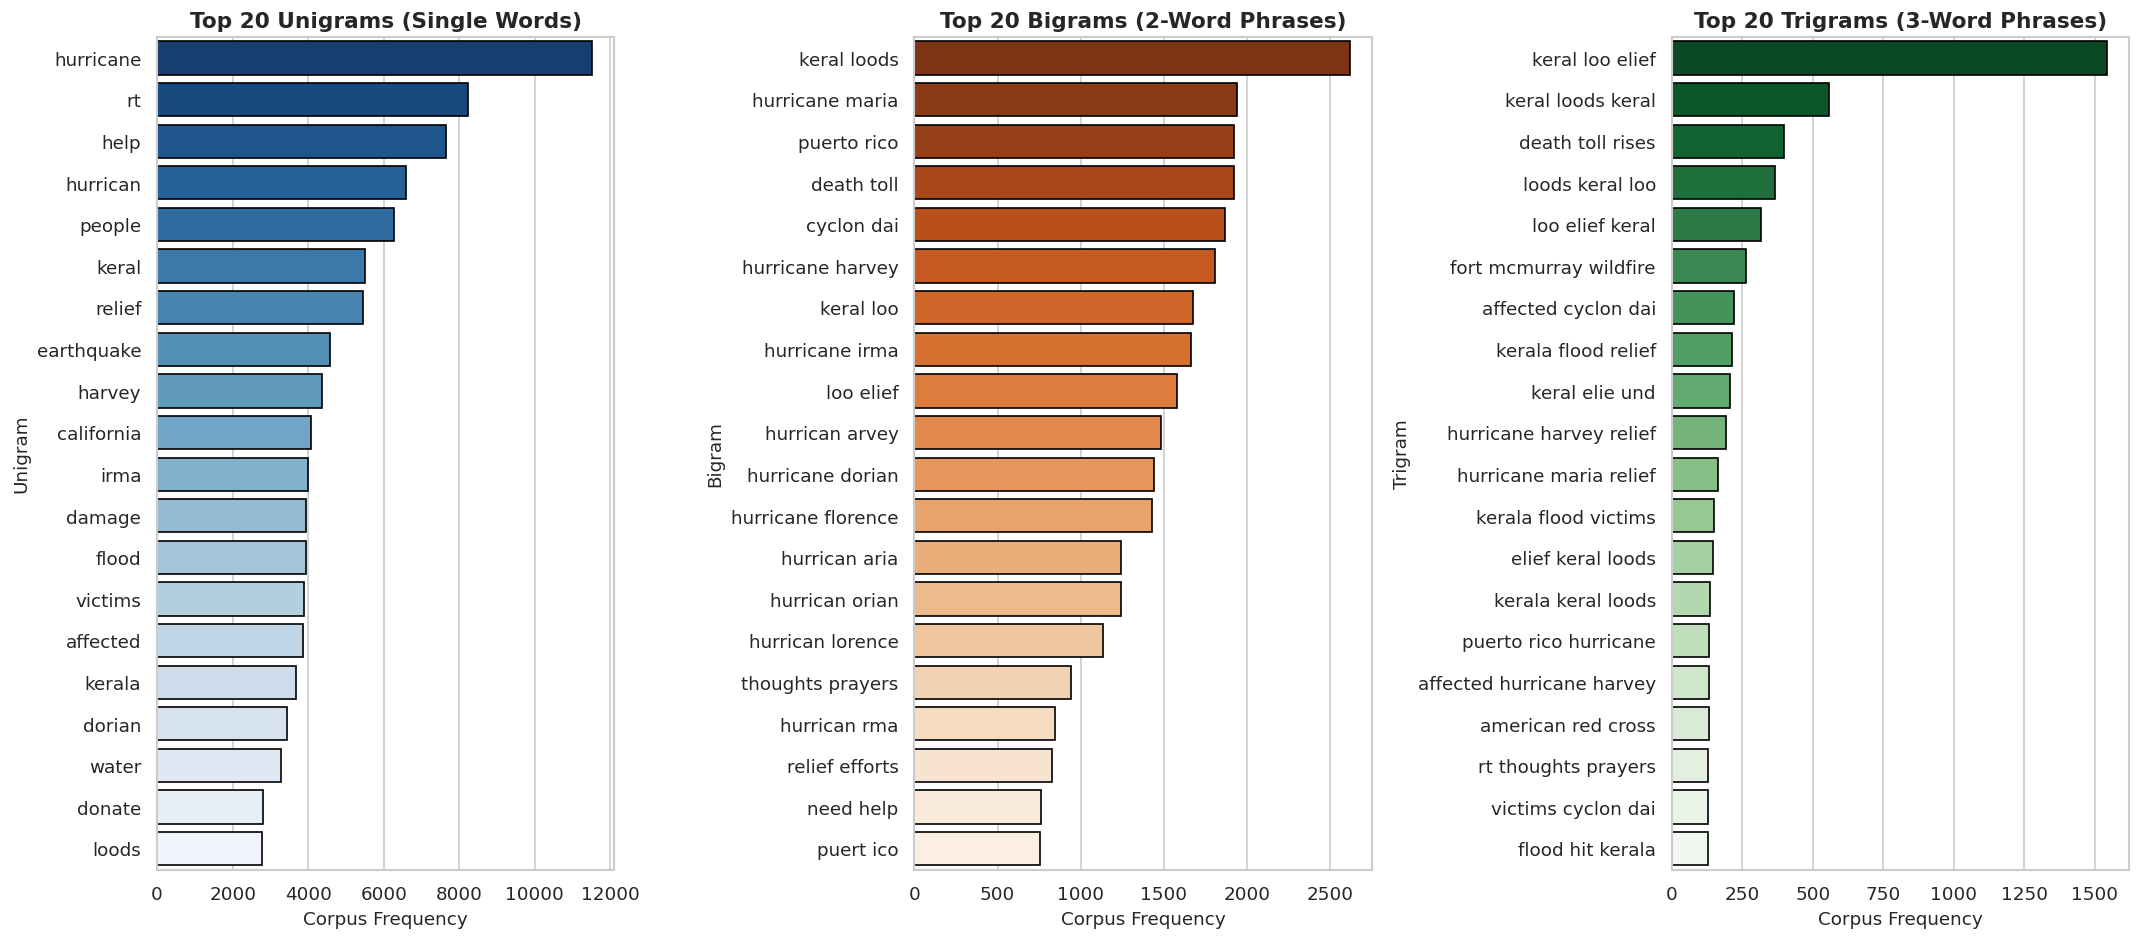

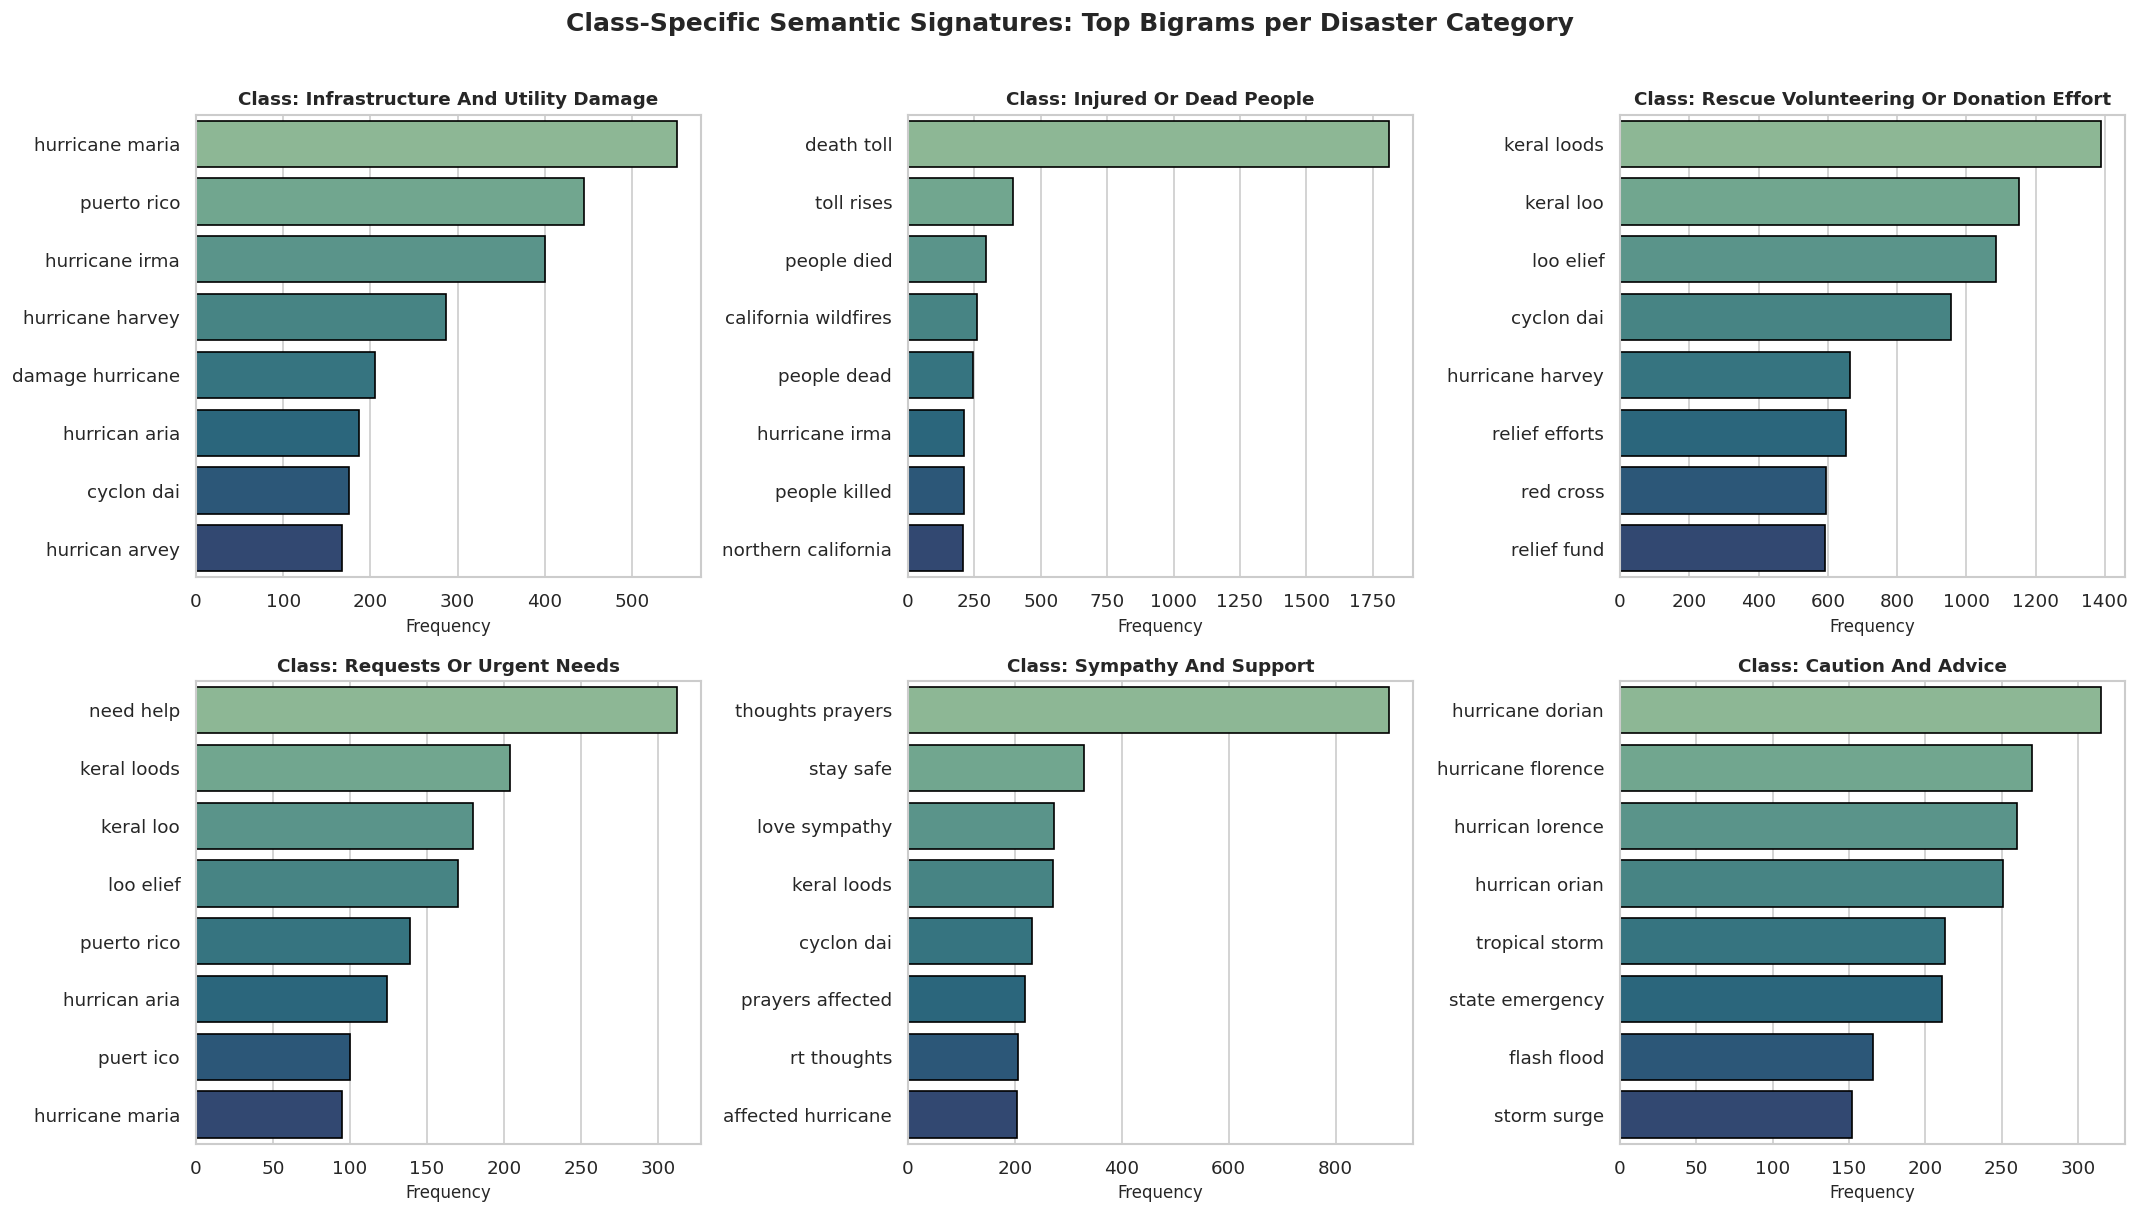

In [16]:
# Helper function for N-Gram extraction using clean_text
def get_top_ngrams(corpus, ngram_range=(1, 1), top_k=20):
    vec = CountVectorizer(ngram_range=ngram_range, stop_words='english', min_df=3)
    bag = vec.fit_transform(corpus)
    sum_words = bag.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return pd.DataFrame(words_freq[:top_k], columns=['N-Gram', 'Frequency'])

print("[+] Extracting top n-grams across training corpus...")
clean_corpus = train_df['clean_text'].tolist()

top_unigrams = get_top_ngrams(clean_corpus, ngram_range=(1, 1), top_k=20)
top_bigrams = get_top_ngrams(clean_corpus, ngram_range=(2, 2), top_k=20)
top_trigrams = get_top_ngrams(clean_corpus, ngram_range=(3, 3), top_k=20)

# Visualization: Top 20 Unigrams, Bigrams, Trigrams (3-panel plot)
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

# 1. Unigrams
sns.barplot(data=top_unigrams, x='Frequency', y='N-Gram', hue='N-Gram', ax=axes[0], palette='Blues_r', edgecolor='black', legend=False)
axes[0].set_title('Top 20 Unigrams (Single Words)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Corpus Frequency', fontsize=11)
axes[0].set_ylabel('Unigram', fontsize=11)

# 2. Bigrams
sns.barplot(data=top_bigrams, x='Frequency', y='N-Gram', hue='N-Gram', ax=axes[1], palette='Oranges_r', edgecolor='black', legend=False)
axes[1].set_title('Top 20 Bigrams (2-Word Phrases)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Corpus Frequency', fontsize=11)
axes[1].set_ylabel('Bigram', fontsize=11)

# 3. Trigrams
sns.barplot(data=top_trigrams, x='Frequency', y='N-Gram', hue='N-Gram', ax=axes[2], palette='Greens_r', edgecolor='black', legend=False)
axes[2].set_title('Top 20 Trigrams (3-Word Phrases)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Corpus Frequency', fontsize=11)
axes[2].set_ylabel('Trigram', fontsize=11)

plt.tight_layout()
plt.show()

# Per-Class Top N-Grams for Selected Disaster Classes
selected_classes = [
    'infrastructure_and_utility_damage',
    'injured_or_dead_people',
    'rescue_volunteering_or_donation_effort',
    'requests_or_urgent_needs',
    'sympathy_and_support',
    'caution_and_advice'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, cls in enumerate(selected_classes):
    cls_corpus = train_df[train_df['class_label'] == cls]['clean_text'].tolist()
    cls_bigrams = get_top_ngrams(cls_corpus, ngram_range=(2, 2), top_k=8)
    
    sns.barplot(data=cls_bigrams, x='Frequency', y='N-Gram', hue='N-Gram', ax=axes[i], palette='crest', edgecolor='black', legend=False)
    axes[i].set_title(f"Class: {cls.replace('_', ' ').title()}", fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Frequency', fontsize=10)
    axes[i].set_ylabel('')

plt.suptitle('Class-Specific Semantic Signatures: Top Bigrams per Disaster Category', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 7. Clean Dataset Export to `dataset/`

We apply the validated `clean_text` pipeline across `train`, `validation`, and `test` splits and save the cleaned datasets to the `dataset/` directory with `_clean` suffixes in both Parquet and CSV formats.

In [17]:
# Clean all splits
print("[+] Cleaning all splits (Raw vs Clean)...")
for name, df in [('train', train_df), ('validation', val_df), ('test', test_df)]:
    df['clean_text'] = df['tweet_text'].apply(clean_text)

# Export cleaned datasets
out_dir = DATA_DIR
out_dir.mkdir(parents=True, exist_ok=True)

for name, df in [('train', train_df), ('validation', val_df), ('test', test_df)]:
    # Select clean columns
    export_df = df[['tweet_text', 'class_label', 'clean_text']].copy()
    
    parquet_out = out_dir / f"{name}_clean.parquet"
    csv_out = out_dir / f"{name}_clean.csv"
    
    # Save parquet
    export_df.to_parquet(parquet_out, index=False)
    # Save CSV
    export_df.to_csv(csv_out, index=False)
    
    print(f"[SAVED] {parquet_out.name:<25} : {len(export_df):,} samples | Size: {parquet_out.stat().st_size / 1024:.1f} KB")
    print(f"[SAVED] {csv_out.name:<25} : {len(export_df):,} samples | Size: {csv_out.stat().st_size / (1024*1024):.2f} MB")

# Verification of Exported Datasets
print("\n=== Verification of Exported Clean Datasets ===")
for split_name in ['train', 'validation', 'test']:
    p_path = out_dir / f"{split_name}_clean.parquet"
    loaded = pd.read_parquet(p_path)
    print(f"[VERIFIED] {p_path.name:<24} | Shape: {loaded.shape} | Columns: {list(loaded.columns)} | Nulls: {loaded.isnull().sum().sum()}")

[+] Cleaning all splits (Raw vs Clean)...
[SAVED] train_clean.parquet       : 53,531 samples | Size: 9048.6 KB
[SAVED] train_clean.csv           : 53,531 samples | Size: 15.82 MB
[SAVED] validation_clean.parquet  : 7,793 samples | Size: 1347.0 KB
[SAVED] validation_clean.csv      : 7,793 samples | Size: 2.30 MB
[SAVED] test_clean.parquet        : 15,160 samples | Size: 2599.0 KB
[SAVED] test_clean.csv            : 15,160 samples | Size: 4.49 MB

=== Verification of Exported Clean Datasets ===
[VERIFIED] train_clean.parquet      | Shape: (53531, 3) | Columns: ['tweet_text', 'class_label', 'clean_text'] | Nulls: 0
[VERIFIED] validation_clean.parquet | Shape: (7793, 3) | Columns: ['tweet_text', 'class_label', 'clean_text'] | Nulls: 0
[VERIFIED] test_clean.parquet       | Shape: (15160, 3) | Columns: ['tweet_text', 'class_label', 'clean_text'] | Nulls: 0
